# Neural Networks - Gradient Descent

## 1. Why Learning is an Optimisation Problem

- Search problem
- Billions of params

> **Optimisation** = Find the input that makes a function as small or large as possible.

**The maths**:

Model:

```math
f(x, \theta)
```

for a dataset ${(x_i, y_i)}_{i = 1}^N$, we have Loss function:

```math
L(\theta) = \frac{1}{N}\sum_{i=1}^Nl(f(x_i, \theta), y_i)
```

Training is trying to solve:

```math
\theta^* = \arg\min_{\theta}L(\theta)
```

Gradient:

At a point on a foggy mountain, you can't see the valley, but can feel the slop beneath your feet -> Go the the steepest direction.

- Backprop -> Gradient > Gradient descent tells you where to move.

In [1]:
import numpy as np

# Suppose w = 3, L(3) = 0

def loss(w):
    return (w - 3)**2

weights = np.linspace(-2, 8, 11)

print("w\tloss")

for w in weights:
    print(f"{w:.1f}\t{loss(w):.2f}")

w	loss
-2.0	25.00
-1.0	16.00
0.0	9.00
1.0	4.00
2.0	1.00
3.0	0.00
4.0	1.00
5.0	4.00
6.0	9.00
7.0	16.00
8.0	25.00


As w approaches 3, the loss decreases.

## 2. Deriving Gradient Descent from First Principles

How to use Gradient to update params?

Update rule

```math
\theta \leftarrow \theta - \eta\Delta L(\theta)
```

Suppose we have loss $L(\theta)$. We want new param $\theta + \Delta\theta$.

Taylor expansion: with $L(\theta)$ = current loss, $\nabla L(\theta)^T\Delta\theta$ = linear approximation.

```math
L(\theta + \Delta\theta) = L(\theta) + \nabla L(\theta)^T\Delta\theta + O(||\Delta\theta||^2)
```

if our update is small:

```math
L(\theta + \Delta\theta) \approx L(\theta) + \nabla L^T\Delta\theta
```

Then:

```math
\Delta L = L(\theta + \Delta\theta) - L(\theta) = \nabla L^T\Delta\theta
```

New loss must < old loss -> $\Delta L < 0$ -> $\nabla L^T\Delta\theta < 0$

### Direction

> Which direction should $\Delta\theta$ move?

Let $u$ = direction with $||u|| = 1$, $\alpha$ = step size, move $\Delta\theta = \alpha u$. Then $\nabla L = \alpha\Delta L^Tu$.

**Cauchy-Schwarz Inequality**

Since $a^Tb = ||a||||b||\cos\theta$, $||u|| = 1$, we have:

```math
\nabla L^T u = ||\nabla L||\cos\theta
```

The smallest possible value occurs when $\cos\theta = -1$. Then:

```math
u = - \frac{\nabla L}{||\nabla L||}
```

> **Direction of Steepest Descent**: The negative gradient gives the largest decrease

### Step length

Define new scalar $\eta > 0$, absorb the normalisation into step size, we have:

```math
\Delta\theta = \alpha\frac{\nabla L}{||\nabla L||} = -\eta \nabla L
```

$\eta$ is called **learning rate**. And the **gradient descent** is defined:

```math
\theta_{\text{new}} = \theta - \eta\nabla L(\theta)
```

To understand why this decrease loss, we have *Taylor approximation*:

```math
\Delta L \approx \nabla L^T(-\eta\nabla L) = -\eta\nabla L^T\nabla L
```

But $\nabla L^T\nabla L = ||\nabla L||^2$, then we obtain:

```math
\Delta L = -\eta ||\nabla L||^2
```

which is $<= 0$.

> For sufficiently small steps, moving in the negative gradient direction cannot increase the first-order approximation of the loss.

In [ ]:
import numpy as np

class GradientDescent:

    def __init__(self, learning_rate=.01):
        self.lr = learning_rate

    def step(self, parameters, gradients):
        """
        Input:
            parameters: list of numpy arrays
            gradients: list of numpy arrays

        Returns:
            updated parameters
        """
        for p, g in zip(parameters, gradients):
            p -= self.lr * g

### The reason why $\nabla L(\theta)$ is gradient

- Because $L(\theta)$ is a function of a vector, not a single variable.
- $\theta$ is a vector collecting multiple variables.

> $\nabla$ is an operator, take the partial derivative with respect to every variable.

## 3. One Parameter Gradient Descent

```math
w_{\text{new}} = w - \eta \frac{\partial L}{\partial w}
```

- **Convergence**: slowly reach optimum
- **Oscillatory convergence**: flip - and +
- **Critical learning rate**: $w_{\text{new}}$ is optimum after *one update*.
- **Divergence**: loss explodes.

In [ ]:
import numpy as np

def loss(w):
    return w**2 # assume min(w) = 0

def grad(w):
    return 2*w

def gradient_descent(w0, learning_rate, steps):
    w = w0

    for step in range(steps):
        print(f"{step: <5} {w: <12.6f} {loss(w): <12.6f}")

        w -= learning_rate * grad(w)
    
    return w

In [ ]:
# convergence
gradient_descent(w0=5, learning_rate=.1, steps=10)

0     5.000000     25.000000   
1     4.000000     16.000000   
2     3.200000     10.240000   
3     2.560000     6.553600    
4     2.048000     4.194304    
5     1.638400     2.684355    
6     1.310720     1.717987    
7     1.048576     1.099512    
8     0.838861     0.703687    
9     0.671089     0.450360    


0.5368709120000001

In [7]:
# Oscillatory convergence
gradient_descent(w0=5, learning_rate=.6, steps=10)

0     5.000000     25.000000   
1     -1.000000    1.000000    
2     0.200000     0.040000    
3     -0.040000    0.001600    
4     0.008000     0.000064    
5     -0.001600    0.000003    
6     0.000320     0.000000    
7     -0.000064    0.000000    
8     0.000013     0.000000    
9     -0.000003    0.000000    


5.119999999999991e-07

In [8]:
# Divergence

gradient_descent(w0=5, learning_rate=1.2, steps=10)

0     5.000000     25.000000   
1     -7.000000    49.000000   
2     9.800000     96.040000   
3     -13.720000   188.238400  
4     19.208000    368.947264  
5     -26.891200   723.136637  
6     37.647680    1417.347809 
7     -52.706752   2778.001706 
8     73.789453    5444.883345 
9     -103.305234  10671.971355


144.62732748799996

## 4. Multi-dimensional Gradient Descent

> How to descend millions or billions of parameters simultaneously?

```math
\theta = \begin{bmatrix}
    \theta_1 \\
    \theta_2 \\
    \cdots \\
    \theta_n
\end{bmatrix} \Rightarrow

\nabla L = \begin{bmatrix}
    \frac{\partial L}{\partial \theta_1} \\
    \frac{\partial L}{\partial \theta_2} \\
    \cdots \\
    \frac{\partial L}{\partial \theta_n}
\end{bmatrix}
```

In [ ]:
# After implementing GradientDescent, use numerical_gradient to verify.

class GradientDescent:

    def __init__():
        ...

    def step(self, params, grads):
        ...

## 5. Learning Rate

> Why learning rate?

- Learning rate = how large the step be.
- We can only take small steps -> learning rate. Else, we'll step away from optimum.

## 6. Implementing Gradient Descent (NumPy)

In [ ]:
# miror torch.nn.Parameter

import numpy as np

class Parameter:
    """
    Remember in the past, we stored:
        W = np.random.randn(...)
    Now we create Parameter to store grad, and later:
        - momentum
        - variance
        - step count
    """

    def __init__(self, data):
        ...

    def zero_grad(self):
        ...

    def __repr__(self):
        ...

In [ ]:
class Optimiser:
    """
    Base class, applied to:
        - SGD
        - Adam
        - ...
    """
    
    def __init__(self, parameters):
        ...
    
    def zero_grad(self):
        """
        Without zero_grad, gradient is accumulated every iteration.
        """

    def step(self):
        ...

In [ ]:
# Training loop

for epoch in range(epochs):
    optimiser.zero_grad()               # reset gradient every iteration
    predictions = model(X)              # predict
    loss = criterion(predictions, y)    # compute loss
    model.backward()                    # gradient
    optimiser.step()                    # gradient descent (update params)

## 7. Connecting Backpropagation to Gradient Descent

In [10]:
# Small Experiment
import numpy as np


class LinearRegression:

    def __init__(self):
        self.w = np.random.randn()
        self.b = np.random.randn()

    def forward(self, x):
        return self.w * x + self.b

    def loss(self, y_pred, y):
        return np.mean((y_pred - y) ** 2)

    def backward(self, x, y_pred, y):
        n = len(x)

        error = y_pred - y

        dw = (2 / n) * np.sum(error * x)
        db = (2 / n) * np.sum(error)

        return dw, db

    def step(self, dw, db, lr):

        self.w -= lr * dw
        self.b -= lr * db

In [ ]:
model = LinearRegression()

lr = 0.01

for epoch in range(1000):
    y_pred = model.forward(x)
    loss = model.loss(y_pred, y)
    dw, db = model.backward(x, y_pred, y)
    model.step(dw, db, lr)

    if epoch % 100 == 0:
        print(epoch, loss)

## 8. Training Our First Neural Network

```
TRAIN()
    for epoch
        FORWARD()
        LOSS()
        BACKWARD()
        GRADIENT-DESCENT()
```

In [12]:
import numpy as np

class LinearModel:

    def __init__(self):
        self.w = np.random.randn(1, 1)
        self.b = np.zeros((1,))

    def forward(self, X):
        return X @ self.w + self.b

    def loss(self, prediction, target):
        return np.mean((prediction-target)**2)
    
    def backward(self, X, prediction, target):
        n = len(X)
        error = prediction-target
        dY = (2/n)*error
        dw = X.T @ dY
        db = np.sum(dY, axis=0)
        return dw, db
    
    def step(self, dw, db, lr):
        self.w -= lr*dw
        self.b -= lr*db

In [ ]:
model = LinearModel()
lr = 0.01
epochs = 1000
history = []

for epoch in range(epochs):
    prediction = model.forward(X)
    loss = model.loss(prediction, Y)
    dw, db = model.backward(
        X,
        prediction,
        Y
    )
    model.step(dw, db, lr)
    history.append(loss)

    if epoch % 100 == 0:
        print(epoch, loss)

## 9. Numerical Verification

- **Always verify**, especially newly implemented gradient -> Then scale to large models.
- Automatic verification.
- No calculus
- Analytical gradient agrees Numerical gradient.
- Expensive -> Only for debug.
- Forward difference.
- Central difference - all frameworks use this.
  - O(P^2) for P := # params
  - Total compexity = # passes * cost per past = 2P * O(P) = O(P^2)
- Relative error

```math
\text{Relative Error } = \frac{|g_{\text{analytic|}} - g_{\text{numeric}}}{\max(1, |g_{\text{analytic|}}|, |g_{\text{numeric}}|)}
```

- Threshold:
  - $< 10^{-7}$: Excellent
  - $10^{-7}-10^{-5}$: Usually acceptable
  - $10^{-5}$: Suspicious
  - $> 10^{-4}$: Likely a bug
  - $> 10^{-2}$: Almost certainly wrong
- Not a part of training, but engineering process.

In [1]:
import numpy as np


class LinearRegression:

    def __init__(self):
        self.W = np.random.randn(2, 1)
        self.b = np.zeros((1,))

    def forward(self, X):
        return X @ self.W + self.b

    def loss(self, X, y):
        pred = self.forward(X)
        return np.mean((pred - y) ** 2)

    def backward(self, X, y):
        N = X.shape[0]
        pred = self.forward(X)
        dL_dpred = 2 * (pred - y) / N
        dW = X.T @ dL_dpred
        db = np.sum(dL_dpred)
        return dW, db

In [2]:
def numerical_gradient(model, X, y, eps=1e-5):
    grad = np.zeros_like(model.W)

    for i in range(model.W.shape[0]):
        for j in range(model.W.shape[1]):
            original = model.W[i, j]

            model.W[i, j] = original + eps
            loss_plus = model.loss(X, y)

            model.W[i, j] = original - eps
            loss_minus = model.loss(X, y)

            grad[i, j] = (loss_plus - loss_minus) / (2 * eps)

            model.W[i, j] = original

    return grad

In [3]:
np.random.seed(42)

X = np.random.randn(10, 2)

true_W = np.array([[2.0], [-3.0]])

y = X @ true_W + 0.5

model = LinearRegression()

analytic_grad, _ = model.backward(X, y)

numeric_grad = numerical_gradient(model, X, y)

print("Analytical:")
print(analytic_grad)

print()

print("Numerical:")
print(numeric_grad)

print()

error = np.max(np.abs(analytic_grad - numeric_grad))

print("Maximum Error:", error)

Analytical:
[[1.27938049]
 [5.07785964]]

Numerical:
[[1.27938049]
 [5.07785964]]

Maximum Error: 7.596701045997634e-11


In [ ]:
# In real large models

for parameter in model.parameters():
    analytic = parameter.grad
    numeric = numerical_gradient(parameter)
    compare(analytic, numeric)

In [ ]:
# torch
import torch
from torch.autograd import gradcheck

gradcheck(model, inputs)

## 10. Geometry of Optimisation

- Gradient is not a number, it's a vector

```math
L(x, y) \mapsto \nabla L = \begin{bmatrix} \partial_{x_1} \\ \partial_{x_2} \\ \vdots \\ \partial_{x_d} \end{bmatrix}
```

- Gradient perpendicular to **contour lines**.
- **Hessian** captures curvature.
  - first derivative = slope
  - second derivative = curvature.

```math
H = \begin{bmatrix}
\frac{\partial^2 L}{\partial x^2} & \frac{\partial^2 L}{\partial x \partial y} \\
\frac{\partial^2 L}{\partial y \partial x} & \frac{\partial^2 L}{\partial y^2}
\end{bmatrix}
```

- The Taylor approximation near a point

```math
L(\theta + \Delta) \approx L(\theta) + \nabla L^T\Delta + \frac{1}{2}\Delta^TH\Delta
```

> The gradient provides the local linear trend, while the Hessian adjusts that estimate by accounting for how the slope itself changes.

- Convex optimisation
- Non-convex optimisation
- NNs are non-convex
- Global minima vs local minima
- **Saddle points** (zero gradient but mixed curvature) more common than poor local minima
- Hessian has both positive and negative eigenvalues -> Gradient descent slows near saddle points because the gradient is tiny, not because the solution is optimal.
- **Condition number**: $\mathcal{K} = \frac{\lambda_{\text{max}}}{\lambda_{\text{min}}}$
  - small: elongated valley -> slow zig zag optimisation
  - large: spherical -> rapid convergence

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def loss(x, y):
    return x**2 + 5*y**2

Matplotlib is building the font cache; this may take a moment.


In [ ]:
# Generate surface, curvature along x and y.

x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)

X, Y = np.meshgrid(x, y)
Z = loss(X, Y)

In [7]:
# Gradient

def gradient(theta):
    x, y = theta
    return np.array([2*x, 10*y])

In [8]:
# Gradient descent

theta = np.array([2.5, 2.0])

trajectory = [theta.copy()]

lr = 0.1

for _ in range(30):
    theta = theta - lr * gradient(theta)
    trajectory.append(theta.copy())

trajectory = np.array(trajectory)

A contour plot takes that 3D bowl and looks at it from directly above, drawing rings that connect points of equal height — exactly like altitude lines on a hiking map. Because your loss has a $5y^2$ term (steeper in y than x), the bowl isn't symmetric — it's stretched, so the contour rings will look like ellipses, not circles. That asymmetry is precisely why gradient descent trajectories on this kind of loss often "zig-zag" rather than travelling in a straight line to the minimum.

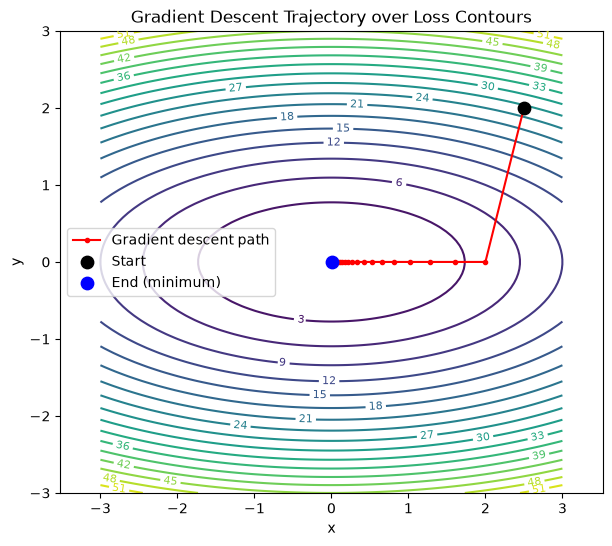

In [9]:
# Plot
plt.figure(figsize=(7, 6))

# 1. The contour map (the "altitude lines")
contours = plt.contour(X, Y, Z, levels=20, cmap='viridis')
plt.clabel(contours, inline=True, fontsize=8)  # optional: numeric labels on rings

# 2. The path taken by gradient descent
plt.plot(trajectory[:, 0], trajectory[:, 1],
         color='red', marker='o', markersize=3, linewidth=1.5,
         label='Gradient descent path')

# 3. Mark start and end clearly
plt.scatter(*trajectory[0], color='black', s=80, zorder=5, label='Start')
plt.scatter(*trajectory[-1], color='blue', s=80, zorder=5, label='End (minimum)')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Gradient Descent Trajectory over Loss Contours')
plt.legend()
plt.axis('equal')  # crucial — keeps the ellipses looking like true ellipses
plt.show()


**Verify the steepest descent property**

Pick any vector $u$, compute:

```math
D_uL = \nabla L^Tu
```

Cauchy-Schwarz inequality

```math
|\nabla L^Tu| \le ||\nabla L||||u|| = ||\nabla L||
```

Equality holds only when $u$ is parallel or anti-parallel to the gradient.

## 11. Researcher's Perspective

The perspective of true optimisation researchers.

- Backprop is not optimisation, it only computes gradient.
- Gradients hide other info, we can also incorporate additional information.
- Adam is dominant
- Scale -> easier optimisation. Yet we still don't know why!!!
- Optimisation = system, not a single equation $\theta \leftarrow \theta - \eta \nabla L$.

In [10]:
import numpy as np

np.random.seed(42)
N = 1000
X = np.random.randn(N,2)
true_w = np.array([[2],[-3]])
y = X @ true_w + 0.5

def full_gradient(W):
    pred = X @ W
    dL = 2*(pred-y)/N
    return X.T @ dL

def minibatch_gradient(W,batch_size=32):
    idx = np.random.choice(N,batch_size)
    xb = X[idx]
    yb = y[idx]
    pred = xb @ W
    dL = 2*(pred-yb)/batch_size
    return xb.T @ dL

W = np.random.randn(2,1)
g_full = full_gradient(W)
g_batch = minibatch_gradient(W)

print(g_full)
print(g_batch)

[[-4.95631551]
 [ 5.81518427]]
[[-9.14395145]
 [ 8.80101684]]


In [11]:
# Measuring convergence empirically

grads = []

for _ in range(500):
    grads.append(minibatch_gradient(W))

avg_grad = np.mean(grads, axis=0)

print("Full gradient:\n", g_full)
print("Average mini-batch gradient:\n", avg_grad)

Full gradient:
 [[-4.95631551]
 [ 5.81518427]]
Average mini-batch gradient:
 [[-4.83456276]
 [ 5.73119001]]
